# Session 2 — Understanding the problem

**DS4Eng · Applied Data Science for Engineering · Organisation Lab**
Wednesday 23 September 2026 · Alfons Marquès

---

## From a file you have never opened, to a document that says what every column means

Last week we took a file apart and found that the documentation was wrong about it.
Today we do that on purpose, and we write down what we find.

We walk into a garment factory in Bangladesh: twelve teams, two departments, three
months of daily production records. By the end of the session you will know how to open
a file you have never seen, work out what is really inside it, and say so in writing.

## How this notebook works

Three zones, and you only ever touch two of them.

| Zone | What it is | Do you touch it? |
|---|---|---|
| ⚙️ **CONFIGURE** | The few settings of the session | **Yes** — this is the only place |
| 🔧 **ENGINE** | Helper functions that do the plumbing | **No** — run it and forget it |
| 🔬 **WORK** | Where the session actually happens | **Yes** |

**Today is different from last week.** For the first 75 minutes every piece of code is
already written and already run: the answers are printed below each cell. You are not
typing, you are reading and watching. Six times I will ask you to **change one line and
run it again** — those are marked ✋ and they are the point of the first half.

Then, at the 75 minute mark, you take over.

> **If you get lost, do not sit there.** Everything in the first half is printed on the
> page. Put your hand up, and keep moving.

## How to use this notebook in Colab

1. **`File → Save a copy in Drive`.** Work on your copy, not on mine.
2. **`Shift + Enter`** runs the cell you are on and moves to the next one.
3. **Do not press `Run all` right now.** The outputs you can see were saved on purpose,
   so that the session works even if the room's wifi does not. We will run cells one at
   a time, together.
4. Colab forgets everything after about 90 minutes of inactivity. If the page goes quiet
   on you, run the 🔧 ENGINE cell and then the cells you need, one at a time.
5. **Double-click a text cell to write in it**, and `Shift + Enter` to render it again.
   You will need this for E7.

## Words we will use today

Plain meanings first, so nobody has to guess. This is the only cell you may want to come
back to.

**EDA (exploratory data analysis)** — looking at a file on purpose, before asking it any
question, to find out what is actually inside it.
**dataset** — one file of data. Today: one table.
**row** — one observation. Here: one team, on one day, in one department.
**column** — one thing that was measured.
**DataFrame** — a table held in Python's memory, with rows and columns, like a sheet.
**notebook** — this page: a stack of text cells and code cells that you run in order.
**cell** — one block of this page. The grey ones hold code.

**garment** — a piece of clothing: the thing this factory makes.
**department** — the stage of production. This factory has two: sewing and finishing.
**team** — a group of workers on one production line. There are twelve.
**SMV (standard minute value)** — how many minutes one garment *should* take. A high SMV
means a hard garment.
**WIP (work in progress)** — garments that have been started and not finished.
**incentive** — a bonus paid to a team, in Bangladeshi taka.
**idle time** — minutes the line was stopped.
**targeted productivity** — the goal a team was given for the day, on a 0 to 1 scale.
**actual productivity** — what the team delivered, on the same scale.
**target** — the column you are trying to explain. Today it is `actual_productivity`.
**rate** — a count divided by a total. Between 0 and 1.
**dataset card** — the page where whoever published the data describes it. It describes
what they *meant* to publish.
**threshold** — a number *you* choose to split cases into two groups. It is a decision,
not a measurement.

## Where we left off

Last week, on a different file, three things happened that are worth remembering:

- The dataset card calls the first column `UID`. In the file it is `UDI`. You will open
  that same file again at the 75 minute mark.
- The description said a machine is marked as failed when at least one cause is flagged.
  In twenty seven rows, that was not true.
- We never opened a single picture.

Today we fix the last one, and we turn the first two into a habit.

> The documentation describes what someone **meant** to publish.
> The data is what actually arrived.

## ⚙️ CONFIGURE

Everything the session can be steered by, in one place.

In [1]:
# Where the data comes from
DATA_URL = "https://raw.githubusercontent.com/DATANINJA-dev/ds4eng-lab/main/data/garments_worker_productivity.csv"

# The column we are trying to explain
TARGET = "actual_productivity"

# The line we draw between "hit the goal" and "missed it"
MIN_TARGET = 0.70          # <- micro-stop 1 · try 0.80, run again, then put 0.70 back

# The columns whose values are labels, not quantities
CATEGORICAL = ["department", "team", "day", "quarter"]

print("Configured. Target:", TARGET, "| threshold:", MIN_TARGET)

Configured. Target: actual_productivity | threshold: 0.7


## 🔧 ENGINE

Plumbing. Run it once and forget it — nothing below this cell needs you to understand it
today. Come back to it in week four, when it will read like ordinary Python.

In [2]:
import io
import urllib.request
import zipfile

import pandas as pd
import matplotlib.pyplot as plt

# Show wide tables without wrapping them into an unreadable mess
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

# Make every picture readable from the back of the room
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.grid": True,
    "grid.alpha": 0.3,
})


def load_data(url=None):
    """Download the file and hand it back as a table.

    Accepts a plain .csv or a .zip with one .csv inside, so the same line works whether
    the file is served from our repository or straight from the original archive.
    """
    url = url or DATA_URL
    raw = urllib.request.urlopen(url, timeout=60).read()
    if url.endswith(".zip"):
        bundle = zipfile.ZipFile(io.BytesIO(raw))
        inside = [n for n in bundle.namelist() if n.lower().endswith(".csv")][0]
        return pd.read_csv(bundle.open(inside))
    return pd.read_csv(io.BytesIO(raw))


def pct(part, whole):
    """Turn a count into a percentage, rounded to one decimal."""
    return round(100 * part / whole, 1)


print("Engine ready.")

Engine ready.


# 0 · Why we look before we ask

An EDA is not a warm-up. It is the part of the job where you find out whether the
question you were going to ask can even be asked of this file.

Four things go wrong when you skip it, and all four are expensive later:

- two groups are measured on such different work that comparing their rates is meaningless,
- the same category is written two different ways, so you count it twice,
- an empty cell is read as a zero, or a zero is read as an empty cell,
- a value is impossible, and nobody notices because nobody looked.

Today all four of them are in the file. You will find them in about half an hour.

### The factory we are walking into

A garment factory in Bangladesh, early 2015. Twelve teams, two departments, one row per
team per day **in each department**.

- **sewing** puts the garment together. It is the slow part.
- **finishing** irons, folds, checks and packs. It is the fast part.

Every team is given a goal each morning, on a scale from 0 to 1, and at the end of the
day somebody writes down what they achieved. Those two columns — the goal and the result
— are what the whole session turns on.

### The question of the day

> **Who is hitting the goal they were given, who is not, and can I trust the file that
> says so?**

Keep it in your head. Every step below is either an answer to it, or a reason to distrust
the answer.

## Words we will use today · the Python ones

**categorical** — a column whose values are labels, even when they are stored as numbers.
**variable** — a name stuck to a value, so you can use the name instead of the value.
**type** — what kind of value something is. Python cares, and so should you.
**list** — an ordered box of things, in square brackets. Counting starts at **0**.
**dictionary** — a box of labelled things, in curly brackets: each **key** points to one
**value**.
**data dictionary** — one written line per column, saying what it measures, in what unit,
and whether it is a number or a label. **This is what we produce today.**
**shape** — `(rows, columns)`. The size of the table.
**tuple** — a small fixed group of values you read together, in round brackets. `(1197, 15)`
is one.
**loop** — doing the same thing once for every item in a list or a dictionary.
**function** — a named block of code that takes **arguments** and gives back a **return**
value.
**argument** — what you hand a function when you call it.
**named argument** — an argument you label as you pass it, like `bins=30` or `kind="bar"`,
so you do not have to remember the order.
**method** — a function that belongs to a thing. The dot means *"ask this thing to…"*:
`df.head()` asks the table for its first rows.
**chain** — several methods one after another, read left to right. Each link hands its
result to the next.
**accessor** — a doorway to a family of methods. `.str` is the one we use: it hands a text
method to every row at once.
**library** — code somebody else wrote, that you can use. **pandas** gives Python tables;
**matplotlib** draws the pictures.

# 1 · The Python you need — and not one line more

There is a lot of Python. Almost none of it is needed to read and write the twenty five
lines that make up a first analysis. So we do those, and nothing else.

Everything you see below is written with the factory's own numbers. No `x = 5`.

> 🏃 **Already know Python?** Jump to **`2 · The method`** and read ahead — then, for the
> second hour, you are your neighbour's driver. Explaining it is the fastest way to find
> out whether you actually knew it.

### 1.1 · Variables, and the four types

A **variable** is a name stuck to a value. You write the name, Python gives you back the
value. The four types below are the only ones today.

In [3]:
department = "sewing"        # str   - text, always in quotes
n_workers = 59               # int   - a whole count
goal_today = 0.80            # float - a number with a decimal point
achieved = 0.94              # float

print(department, type(department))
print(n_workers, type(n_workers))
print(goal_today, type(goal_today))

sewing <class 'str'>
59 <class 'int'>
0.8 <class 'float'>


Notice that `type()` tells you what Python *thinks* something is. It will matter in step 3,
when we find a column of labels that Python decided was a number.

In [4]:
# A comparison does not compute a quantity: it answers yes or no.
hit_the_goal = achieved >= goal_today

print("achieved:", achieved, "| goal:", goal_today)
print("hit the goal?", hit_the_goal, type(hit_the_goal))

achieved: 0.94 | goal: 0.8
hit the goal? True <class 'bool'>


That `True` is the smallest and most useful thing in the session. Hold on to it: in forty
minutes we will make 1197 of them at once, add them up, and that sum will be the answer
to the question of the day.

## ✋ Micro-stop 1 · a threshold is a decision

Go up to the ⚙️ **CONFIGURE** cell and change `MIN_TARGET` from `0.70` to `0.80`. Run that
cell again, and then run this one.

Nothing about the factory changed. Only what we decided to call *good enough*.

`MIN_TARGET` is a threshold **you** choose. The goal each team was given is a different
thing, and it lives in the file. In forty minutes you will see both numbers printed side
by side, and they will not agree.

<details>
<summary><b>Put it back</b></summary>

```python
MIN_TARGET = 0.70
```

</details>

In [5]:
print("A team is doing well today if it reaches", MIN_TARGET)

A team is doing well today if it reaches 0.7


### 1.2 · Reading a chain of dots

Almost every line today looks like this:

```
df.groupby("team")[TARGET].mean().sort_values().plot(kind="bar")
```

That is not one instruction, it is five, read **left to right**. A **method** is a
function that belongs to a thing, and the dot means *"ask this thing to…"*:

| Piece | Ask it to… | What you get back |
|---|---|---|
| `df` | — | the whole table |
| `.groupby("team")` | split by team | twelve piles |
| `[TARGET]` | keep one column | twelve piles of one column |
| `.mean()` | average each pile | twelve numbers |
| `.sort_values()` | sort them | twelve sorted numbers |
| `.plot(kind="bar")` | draw them | a picture |

Each link hands its result to the next. If a chain ever confuses you, cut it after any dot
and run it: you will see exactly what that link produced.

### 1.3 · Lists

A **list** is an ordered box, written in square brackets. We need exactly one today: the
list of columns whose values are labels rather than quantities.

In [6]:
CATEGORICAL_DEMO = ["department", "team", "day", "quarter"]

print("how many:", len(CATEGORICAL_DEMO))
print("the first one:", CATEGORICAL_DEMO[0])

how many: 4
the first one: department


**Counting starts at zero.** `[0]` is the first item, not the second. If you come from
MATLAB or R this is the single most common way to lose ten minutes, so it is worth the
ten seconds now.

## ✋ Micro-stop 2 · base zero

Change `CATEGORICAL_DEMO[0]` above to `CATEGORICAL_DEMO[1]` and run it. Which one comes
back? Now try `CATEGORICAL_DEMO[4]` and read the error message — Python is telling you
there is no fifth item, because the last one is `[3]`.

<details>
<summary><b>Put it back</b></summary>

```python
print("the first one:", CATEGORICAL_DEMO[0])
```

</details>

### 1.4 · Dictionaries — and *the* data dictionary

A **dictionary** is a box of labelled things: each **key** points to one **value**. In
curly brackets.

And here is the point of the session. A **data dictionary** is just this: the key is the
column name, the value is what that column means. It is not a Python exercise. It is the
document you are going to hand in.

In [7]:
DATA_DICTIONARY = {}

DATA_DICTIONARY["smv"] = "standard minute value - minutes one garment should take"
DATA_DICTIONARY["wip"] = "work in progress - garments started and not finished"
DATA_DICTIONARY["targeted_productivity"] = "the goal the team was given, 0 to 1"
DATA_DICTIONARY["actual_productivity"] = "what the team delivered, 0 to 1"

print("entries so far:", len(DATA_DICTIONARY))
print("smv means:", DATA_DICTIONARY["smv"])

entries so far: 4
smv means: standard minute value - minutes one garment should take


We add the entries one line at a time on purpose. You can also write the whole thing
between curly brackets in one go, but writing fifteen pairs with commas and quotes,
first time, while the class moves on, is a minefield. One line, one column.

## ✋ Micro-stop 3 · you write it, you do not receive it

Add a line to the cell above for a column we have not described yet, and run it:

```python
DATA_DICTIONARY["idle_men"] = "workers with nothing to do while the line was stopped"
```

The count goes up, and your sentence is now part of the document. That is the whole job.

### 1.5 · Loops

A **loop** does the same thing once for every item. We use this one three times today —
here, in step 5 and in step 8 — and then pandas does the repeating for us, a whole column
at a time.

In [8]:
for column, meaning in DATA_DICTIONARY.items():
    print(column, "->", meaning)

smv -> standard minute value - minutes one garment should take
wip -> work in progress - garments started and not finished
targeted_productivity -> the goal the team was given, 0 to 1
actual_productivity -> what the team delivered, 0 to 1


Two things just happened that are worth naming.

**A tuple.** `.items()` hands back *pairs*, and `column, meaning` unpacks each pair into
two names. You will meet another pair in two minutes: `df.shape` answers `(1197, 15)` —
rows first, columns second. A **tuple** is just that: a small fixed group of values you
read together.

**No counter.** We looped over *things with names*, never over numbers. If you come from
MATLAB you may want to write `for i = 1:12`, and from R `for (i in 1:12)`. Both are a
syntax error here. Python's version is `range(12)`, which gives `0, 1, … 11` — it starts
at zero and stops *before* the number you wrote. You will not need it today.

### 1.6 · Functions

A **function** is a named block that takes **arguments** and hands back a **return**
value. Three parts, all three visible below.

In [9]:
def hit(actual, target):
    """True when a team reached the goal it was given."""
    return actual >= target


print(hit(0.94, 0.80))
print(hit(0.65, 0.80))

True
False


Two habits to pick up here.

**Named arguments.** When you call something you can say which argument is which:
`plot(kind="bar")`, `hist(bins=30)`, `scatter(x=..., y=..., alpha=0.25)`. Four lines of
this notebook are exactly that, and you will write three of them yourself in E6, this week.

**What goes in, comes in.** A function only sees what you hand it. In MATLAB a function
cannot see your workspace either — in Python the rule is the same: what it needs, you pass
in; what you want out, you `return`.

Scroll up to the 🔧 ENGINE cell and read `pct()`. It is three lines and you now know all
of them: `100 * part / whole`, then `round(..., 1)`. That is where every percentage in
this notebook comes from.

### 1.7 · Imports, and one thing you only need to recognise

`import pandas as pd` brings in somebody else's code and gives it a short **alias**.
Everyone uses `pd` for pandas and `plt` for matplotlib — use the same ones, so that every
answer you find online fits your notebook. It already ran, up in the ENGINE.

One last thing, to **recognise** and not to write: if you see a letter `f` stuck to a
quote, like `f"rows: {n}"`, that is a template and the `{n}` gets replaced by the value.
You do not need it today — but it is what an AI assistant will hand you, and it is what
you will go looking for if you come from `sprintf` or `paste0`.

## Words we will use today · the ones about tables and pictures

**dtype** — the type pandas assigned to a column when it read the file. It guesses, and
it can guess wrong.
**missing value** — a cell with nothing in it. **Not zero, and not empty text.**
**median** — the middle value once they are sorted. Half the rows are below it.
**frequency table** — how many rows fall into each label. In pandas: `value_counts()`.
**aggregation** — one number computed per group: a count, a sum, an average.
**count** — how many rows a number was computed from. **Always report it next to an
average.**
**distribution** — the shape of how one numeric column spreads out across its range.
**histogram** — the picture of a distribution.
**bar chart** — one bar per label, for comparing labels.
**scatter plot** — one dot per row, for seeing whether two numeric columns move together.
**outlier** — a value so far from the rest that it deserves an explanation.
**finding** — one sentence, in plain English, that an engineer who does not know Python
could read and act on.

# 2 · The method — seven steps, in this order

We are not making pictures. We are diagnosing a file, and the pictures are three of the
instruments.

The order is not decorative: each step is the one that makes the next step readable.

1. **Load**, and count what arrived
2. **Look** at the thing
3. **Types** — what did pandas decide each column is?
4. **How many different values** does each column hold?
5. **Count the categories**
6. **What is missing**
7. **The summary you should never trust alone**

Then a first picture, the question of the day, and two more that answer it.

### Step 1 · Load, and count what arrived

In [10]:
df = load_data()

print("shape (rows, columns):", df.shape)
print("exact duplicate rows:", df.duplicated().sum())
print("duplicated team-day-department:",
      df.duplicated(subset=["date", "team", "department"]).sum())

shape (rows, columns): (1197, 15)
exact duplicate rows: 0
duplicated team-day-department: 0


1197 rows, 15 columns, and no row is repeated — not as a whole, and not as a
team-day-department either. So the unit of observation is settled: **one row is one team,
on one day, in one department.** Everything we compute from here on is per team-day.

The dataset card for this file (archive.ics.uci.edu/dataset/597) types `wip`, `idle_time`
and `no_of_workers` as integers. In the file all three arrived as decimals, and `info()`
in step 3 will show it.

### Step 2 · Look at the thing

Never analyse a table you have not looked at. This is a glance, not a lesson — we are
only getting our bearings.

In [11]:
print("all 15 columns:", list(df.columns))
df.head()[["date", "department", "team", "targeted_productivity", "smv", "wip", TARGET]]

all 15 columns:

 ['date', 'quarter', 'department', 'day', 'team', 'targeted_productivity', 'smv', 'wip', 'over_time', 'incentive', 'idle_time', 'idle_men', 'no_of_style_change', 'no_of_workers', 'actual_productivity']


,date,department,team,targeted_productivity,smv,wip,actual_productivity
0,1/1/2015,sweing,8,0.80,26.16,1108.0,0.940725
1,1/1/2015,finishing,1,0.75,3.94,NaN,0.886500
2,1/1/2015,sweing,11,0.80,11.41,968.0,0.800570
3,1/1/2015,sweing,12,0.80,11.41,968.0,0.800570
4,1/1/2015,sweing,6,0.80,25.90,1170.0,0.800382


Three things to notice in passing, each of which we come back to properly:
the dates are text, not dates · there is an empty cell in `wip` · and the first
department is spelled `sweing`.

### Step 3 · What type is each column?

`info()` answers two questions in one output: what type pandas assigned, and how many
values are actually there.

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

`date` came in as `object`, which is pandas for *text*. The dates in this file are written
`1/1/2015`, and nobody has told pandas that those are days. That is why there is no
time chart today: turning text into dates is a step of its own, and we do it next week.

`team` is an integer, but a team number is a label — you would never average it.
And `wip` has 691 values where every other column has 1197.

### Step 4 · How many different values?

One line, and it plants four findings before we go looking for any of them.

In [13]:
print(df.nunique().to_string())

date                      59
quarter                    5
department                 3
day                        6
team                      12
targeted_productivity      9
smv                       70
wip                      548
over_time                143
incentive                 48
idle_time                 12
idle_men                  10
no_of_style_change         3
no_of_workers             61
actual_productivity      879


Read it as a list of surprises:

- `department` has **3** different values. A factory with two departments.
- `quarter` has **5**. A month with five quarters.
- `day` has **6**. A week with six days.
- `targeted_productivity` has only **9** different values, although pandas calls it a
  number. It is a real quantity, but somebody picked it from a menu of nine agreed levels
  — so it will draw as stripes, not as a cloud.
- `team` has 12: twelve teams, and a number that is a name.

This is also why the four columns in `CATEGORICAL` are those four and not, say, `smv`:
a column whose few values you cannot add up is a label; one you can is a measurement.

### Step 5 · Count the categories

A **frequency table** says how many rows fall into each label: `value_counts()`. We ask it
for all four label columns at once — the loop from 1.5, doing its job again.

In [14]:
for column in CATEGORICAL:
    print(df[column].value_counts().to_string())
    print()

department
sweing        691
finishing     257
finishing     249

team
8     109
2     109
4     105
1     105
9     104
10    100
12     99
7      96
3      95
6      94
5      93
11     88

day
Wednesday    208
Sunday       203
Tuesday      201
Thursday     199
Monday       199
Saturday     187

quarter
Quarter1    360
Quarter2    335
Quarter4    248
Quarter3    210
Quarter5     44



Three surprises in one output.

**`day` has no Friday.** Not a missing value — a fact about this factory, where Friday is
the weekly day off. Saturday is here, with 187 rows, the fewest of the six. A category can
be absent without leaving a single empty cell, and the only way to see it is to count.

**`quarter` has a fifth quarter**, with 44 rows. The first four are blocks of seven days,
and `Quarter5` is whatever is left at the end of the month. The dataset card says a month
is divided into four quarters. The file disagrees.

**And `department` has two rows that look identical.** 257 and 249 of… the same word?

They are not the same word. `value_counts()` prints labels without quotes, so whatever is
hiding is invisible here. Ask for the raw values instead:

In [15]:
print(df["department"].unique())

['sweing' 'finishing ' 'finishing']


There it is: `'finishing '`, with a space at the end, and `'finishing'` without it. Two
labels, one department, 506 rows split in half by a character nobody can see.

(And `sweing` is a typo for *sewing*, in the original file. We leave it exactly as it is.)

In [16]:
# .str hands the text method to all 1197 rows at once. The original column is NOT touched.
df["department_clean"] = df["department"].str.strip()

print(df["department_clean"].value_counts().to_string())

department_clean
sweing       691
finishing    506


Three rows became two: **691 sewing and 506 finishing**.

Notice what we did *not* do: we did not overwrite `department`. We added a column next to
it. Today the job is to find the problem and describe it — deciding what to do about it is
sessions four and five. A one-line fix shown as a diagnosis is fine; a silent fix is how
analyses go wrong.

In [17]:
print("days of the month inside Quarter5:",
      sorted(df.loc[df["quarter"] == "Quarter5", "date"].str.split("/").str[1].unique()))

days of the month inside Quarter5: ['29', '31']


The fifth quarter is the leftover: days 29 and 31. Not 30 — that day never appears in the
file at all, and you would not have found it by reading the dates, only by counting them.

### Step 6 · What is missing?

A **missing value** is a cell with nothing in it. Not a zero, and not empty text.

The way pandas counts them is worth taking apart, because it is the same trick as the
`True` from the first half:

In [18]:
falta = df["wip"].isna()          # one True/False per row

print("first five rows:", list(falta.head()))
print("adding up True and False:", falta.sum())
print()
print(df.isna().sum().to_string())

first five rows: [False, True, False, False, False]
adding up True and False: 506

date                       0
quarter                    0
department                 0
day                        0
team                       0
targeted_productivity      0
smv                        0
wip                      506
over_time                  0
incentive                  0
idle_time                  0
idle_men                   0
no_of_style_change         0
no_of_workers              0
actual_productivity        0
department_clean           0


Adding up a column of `True` and `False` *is* counting. There is no loop, no counter: the
comparison makes 1197 answers and `.sum()` adds them. That is the whole of pandas in one
gesture, and it is the same one we will use in a minute for the question of the day.

506 missing values, all of them in `wip`, none anywhere else. A gap that concentrated in
exactly one column is not an accident. So ask where they are:

In [19]:
# .loc takes a mask and a column: which rows, and which column to show for them
print(df.loc[df["wip"].isna(), "department_clean"].value_counts().to_string())

department_clean
finishing    506


**All 506 are finishing.** Every single one, and none in sewing.

This is not missing data. Nothing was recorded for finishing, not on a single one of its
506 rows, and everything was recorded for sewing, on all 691. A gap that clean is a rule,
not an accident: work in progress is a sewing measurement.

It also explains a detail from step 3: `wip` is a decimal column even though the dataset
card calls it an integer — because a column with gaps in it cannot be stored as whole
numbers. The gap changed the type. But `idle_time` and `no_of_workers` are decimals too,
with no gaps at all, and `no_of_workers` reaches values like 30.5, because a worker can be
shared between two lines. A decimal type has more than one cause.

### Step 7 · The summary you should never trust alone

In [20]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
team,1197.0,6.43,3.46,1.00,3.00,6.00,9.00,12.00
targeted_productivity,1197.0,0.73,0.10,0.07,0.70,0.75,0.80,0.80
smv,1197.0,15.06,10.94,2.90,3.94,15.26,24.26,54.56
wip,691.0,1190.47,1837.46,7.00,774.50,1039.00,1252.50,23122.00
over_time,1197.0,4567.46,3348.82,0.00,1440.00,3960.00,6960.00,25920.00
incentive,1197.0,38.21,160.18,0.00,0.00,0.00,50.00,3600.00
idle_time,1197.0,0.73,12.71,0.00,0.00,0.00,0.00,300.00
idle_men,1197.0,0.37,3.27,0.00,0.00,0.00,0.00,45.00
no_of_style_change,1197.0,0.15,0.43,0.00,0.00,0.00,0.00,2.00
no_of_workers,1197.0,34.61,22.20,2.00,9.00,34.00,57.00,89.00


We transpose it with `.T` so that each variable is a row: eleven short rows read better on
a screen than eleven very wide columns.

Three numbers to take from it, and one warning.

- `actual_productivity` runs from 0.23 to **1.12**. A score out of one, above one.
- `targeted_productivity` goes down to **0.07**. A team was once given a goal of seven
  per cent, and nobody has explained why.
- `incentive` has an average of 38 and a middle value of **0**. More than half the rows
  were paid nothing at all, so the average describes nobody.

The warning: `describe()` only speaks about columns it considers numeric, and it happily
computes an average of `team`, which is meaningless. Read it for the columns you chose,
not for the ones it offers.

## The first picture · a distribution

A **histogram** slices a numeric column into bars and counts how many rows fall in each.
It answers *what shape is this column?*

rows above 1.00: 37

    department_clean  team  targeted_productivity  actual_productivity
766        finishing     1                    0.8                 1.12
767        finishing     2                    0.8                 1.11
730           sweing     1                    0.8                 1.10


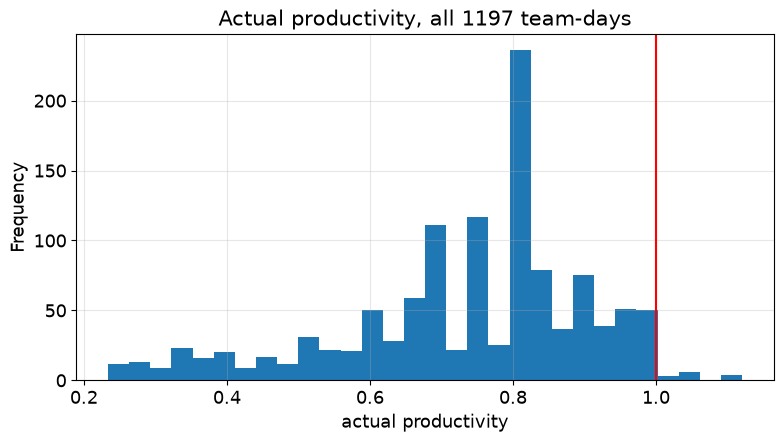

In [21]:
print("rows above 1.00:", (df[TARGET] > 1.0).sum())
print()
print(df.nlargest(3, TARGET)[["department_clean", "team",
                              "targeted_productivity", TARGET]].round(2).to_string())

df[TARGET].plot(kind="hist", bins=30, title="Actual productivity, all 1197 team-days")
plt.axvline(1.0, color="red")
plt.xlabel("actual productivity")
plt.show()

The shape is not the bell you might have expected. There is a tall spike right at 0.80 and
a comb of smaller spikes at round numbers — teams landing exactly on their goal. We come
back to that spike right after the question of the day, because it is the most interesting
thing in the file.

Now be honest about the red line. **It does not reveal the impossible rows.** With thirty
bars one of them straddles 1.00, so most of those rows are drawn on the wrong side of the
line, and thirty seven rows out of 1197 are too few pixels to see anyway. The number came
from the `print`, not from the picture.

That is the lesson, not a failure of the chart: **a picture shows you shape, a count gives
you evidence.** You need both, and you should never report a number you only saw a shape
of. The top row is a finishing team with a goal of 0.80 that recorded 1.12.

## ✋ Micro-stop 4 · the binning is a choice

Change `bins=30` to `bins=10` in the cell above and run it. The comb disappears and the
distribution looks smooth and harmless. Then try `bins=100`.

None of the three is the truth. The data did not move — you changed the question you were
asking it. This is also the clearest example of a named argument: `bins=` is you telling
the function how to do its job.

<details>
<summary><b>Put it back</b></summary>

```python
df[TARGET].plot(kind="hist", bins=30, title="Actual productivity, all 1197 team-days")
```

</details>

## The question of the day

Now the payoff. The function we wrote half an hour ago, applied to the whole table at
once.

In [22]:
df["hit"] = hit(df[TARGET], df["targeted_productivity"])

hits = df["hit"].sum()
print("teams that reached their goal:", hits, "of", len(df),
      "=", pct(hits, len(df)), "%")
print("team-days above the fixed line of", MIN_TARGET, ":",
      pct((df[TARGET] >= MIN_TARGET).sum(), len(df)), "%")
print()
print((100 * df.groupby("department_clean")["hit"].mean()).round(1).to_string())
print()
print(df.groupby("department_clean")[TARGET].agg(["count", "mean", "std"]).round(2).to_string())

teams that reached their goal: 875 of 1197 = 73.1 %
team-days above the fixed line of 0.7 : 69.5 %

department_clean
finishing    59.7
sweing       82.9

                  count  mean   std
department_clean                   
finishing           506  0.75  0.20
sweing              691  0.72  0.15


`hit(...)` was written for two numbers and it just ran on 1197 rows without being changed.
That is the whole reason we wrote it.

**875 of 1197 reached their goal, 73.1 %.** Split by department, sewing is at 82.9 % and
finishing at 59.7 %.

And now look at the line underneath: finishing has the **higher** average productivity
(0.75 against 0.72). Better average, worse hit rate. Both of those are true at the same
time, which means at least one of them is not measuring what it looks like.

### The paradox, told honestly

Before blaming anybody's work, ask how the numbers got written down.

In [23]:
on_the_nose = (df[TARGET] - df["targeted_productivity"]).abs() < 0.001

print("rows recorded exactly on the goal:", on_the_nose.sum(),
      "=", pct(on_the_nose.sum(), len(df)), "% of all rows")
print()
print((100 * on_the_nose.groupby(df["department_clean"]).mean()).round(1).to_string())
print()
print(on_the_nose.groupby(df["department_clean"]).sum().to_string())
print()
print(df.groupby("department_clean")["smv"].mean().round(2).to_string())

rows recorded exactly on the goal: 402 = 33.6 % of all rows

department_clean
finishing     0.2
sweing       58.0

department_clean
finishing      1
sweing       401

department_clean
finishing     3.89
sweing       23.25


**58 % of sewing rows record an achievement identical to the goal, to three decimals.
In finishing it is 0.2 %.**

So the difference in hit rates is not mainly a fact about who works harder. It is a fact
about **how the two departments write the number down**: in sewing, a very large share of
days are logged as "exactly what we were asked for". That also explains the tall spike in
the histogram.

And the last line closes it: the average standard minute value is 3.89 in finishing
against 23.25 in sewing. They are not doing the same work, they are not measured the same
way, and comparing their rates as if they were is the mistake this session exists to
prevent.

## The second picture · a relationship

A **scatter plot** puts one dot per row, and answers *do these two columns move together?*

different values of targeted_productivity: 9
rows with a goal of 0.80: 540
rows sitting on the diagonal: 402


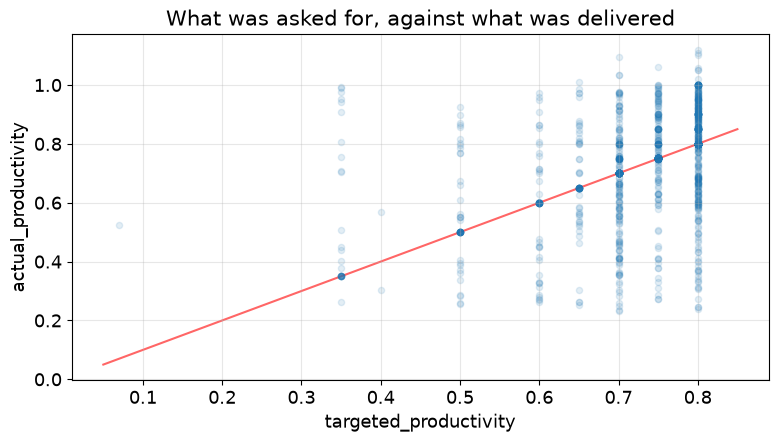

In [24]:
print("different values of targeted_productivity:", df["targeted_productivity"].nunique())
print("rows with a goal of 0.80:", (df["targeted_productivity"] == 0.80).sum())
print("rows sitting on the diagonal:", on_the_nose.sum())

df.plot(kind="scatter", x="targeted_productivity", y=TARGET, alpha=0.12,
        title="What was asked for, against what was delivered")
plt.plot([0.05, 0.85], [0.05, 0.85], color="red", zorder=0, alpha=0.6)
plt.show()

Read it in three moves.

**The vertical stripes.** The dots line up in nine columns because
`targeted_productivity` only ever takes nine values — the thing we suspected in step 4 is
now visible. 540 of the 1197 rows sit in the single stripe at 0.80.

**The diagonal.** Every dot below the red line is a day where the goal was not reached.
Above it, beaten. That is the question of the day, drawn.

**The clot on the line itself.** 402 rows sit exactly on the diagonal, and 401 of them are
sewing. That is the 58 % from a moment ago, seen instead of counted.

## The third picture · a comparison

A **bar chart** puts one bar per label. Before drawing it, print what is behind each bar.

      count  mean   std
team                   
1       105  0.82  0.15
2       109  0.77  0.19
3        95  0.80  0.14
4       105  0.77  0.16
5        93  0.70  0.17
6        94  0.69  0.17
7        96  0.67  0.18
8       109  0.67  0.18
9       104  0.73  0.16
10      100  0.72  0.20
11       88  0.68  0.17
12       99  0.78  0.12


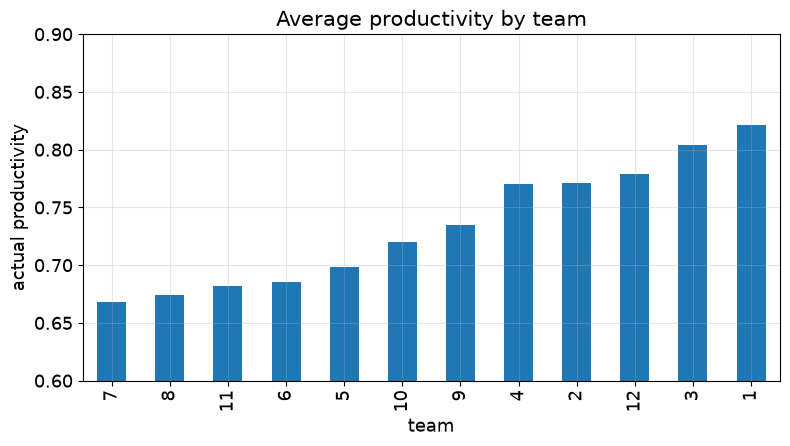

In [25]:
by_team = df.groupby("team")[TARGET].agg(["count", "mean", "std"]).round(2)
print(by_team.to_string())

df.groupby("team")[TARGET].mean().sort_values().plot(
    kind="bar", title="Average productivity by team", ylim=(0.6, 0.9))
plt.ylabel("actual productivity")
plt.show()

Now be careful, because this is the chart most likely to be repeated out loud in a meeting.

What the data supports: **the group of teams at the top of the printed table sits close to
0.80, and the group at the bottom close to 0.68.** That gap is real and it is worth asking
about. The bars are sorted so that the two groups are visible, and the y axis starts at
0.6, not at 0 — say that out loud every time you truncate an axis.

What the data does **not** support: any statement about a single team's position. Look at
the count column — each average rests on between 88 and 109 days. Re-draw those days and
neighbouring bars swap places; the group at the top and the group at the bottom do not.
Saying "the last bar is the worst team" is reading noise as if it were a ranking.

That is why the count and the spread get printed next to the average, every time. A bar
chart without them is a very confident way of being wrong.

(se borra de ahi y se inserta como celda md nueva al final del paso 4, justo despues de la
lectura de `nunique()` que acaba en "one you can is a measurement" y antes de
"### Step 5 · Count the categories")

## ✋ Micro-stop 5 · the list is a decision too

Go up to the ⚙️ **CONFIGURE** cell, add `"no_of_style_change"` to `CATEGORICAL`, and run
it. Then run the frequency tables in step 5 below: one more table comes out, because the
loop does exactly what your list tells it to. Nothing else in the notebook changes.

<details>
<summary><b>Put it back</b></summary>

```python
CATEGORICAL = ["department", "team", "day", "quarter"]
```

</details>

## ✋ Micro-stop 6 · make the impossible rows visible

Go back to the histogram cell and replace the plotting line with this one:

```python
df.loc[df[TARGET] > 1.0, TARGET].plot(kind="hist", bins=6, title="The 37 impossible rows")
```

Same data, a different question. Now the bars only count the rows above 1.00, and they add
up to the 37 the `print` gave you. Nothing changed except where we pointed the camera.

<details>
<summary><b>Put it back</b></summary>

```python
df[TARGET].plot(kind="hist", bins=30, title="Actual productivity, all 1197 team-days")
```

</details>

### Step 8 · Write it down, in the file's own words

The data dictionary from 1.4 has been sitting there since minute 34. Now it has something
to say: these four lines could only be written *after* the seven steps.

In [26]:
DATA_DICTIONARY["wip"] = ("work in progress, garments started and not finished - quantity, "
                          "count of garments - EMPTY in all 506 finishing rows, where it "
                          "means not applicable, never zero")
DATA_DICTIONARY["department"] = ("production stage - label, two of them - arrives with three "
                                 "spellings: 'sweing', 'finishing' and 'finishing '")
DATA_DICTIONARY["targeted_productivity"] = ("goal given to the team that morning - quantity, "
                                            "share of a working day, 0 to 1 - only 9 values "
                                            "are ever used")
DATA_DICTIONARY["actual_productivity"] = ("what the team delivered - quantity, share of a "
                                          "working day, nominally 0 to 1 - 37 rows go above "
                                          "1.00, up to 1.12")

for column, meaning in DATA_DICTIONARY.items():
    print(column, "->", meaning)

smv -> standard minute value - minutes one garment should take
wip -> work in progress, garments started and not finished - quantity, count of garments - EMPTY in all 506 finishing rows, where it means not applicable, never zero
targeted_productivity -> goal given to the team that morning - quantity, share of a working day, 0 to 1 - only 9 values are ever used
actual_productivity -> what the team delivered - quantity, share of a working day, nominally 0 to 1 - 37 rows go above 1.00, up to 1.12
department -> production stage - label, two of them - arrives with three spellings: 'sweing', 'finishing' and 'finishing '


## Five findings

This is how a session like this one ends: not with a chart, with sentences. Five of them,
in plain English, that an engineer who has never opened Python could act on.

Here are the five for this file. Read them and notice how little Python vocabulary they
contain.

1. The file holds 1197 team-days, 691 in sewing and 506 in finishing, with no duplicates.
2. `department` arrives with three labels for two departments, because one of them carries
   a trailing space. Anyone grouping by it without cleaning it first will split finishing
   in two and count 257 days where there are 506.
3. `wip` is empty in 506 rows, and all of them are finishing. This is not missing data:
   a finishing line has no work in progress. It should be read as "not applicable", never
   filled in with a zero.
4. 875 of 1197 team-days reached their goal, 73.1 %. Sewing reports 82.9 % and finishing
   59.7 %, but 58 % of sewing rows record an achievement exactly equal to the goal against
   0.2 % in finishing — so the gap describes recording practice at least as much as
   performance, and the two departments should not be compared on this number.
5. Thirty seven rows report a productivity above 1.00, up to 1.12, on a scale that is
   supposed to stop at one. The dataset card does not mention it.

**Now you do this for a different file.**

# 🔬 YOUR TURN — AI4I 2020

You already know this one: it is the file from last week. 10000 rows, 14 columns, one
machine, one maintenance question.

This time nobody walks you through it.

### 📤 What you hand in

**Deliverable:** one Colab notebook, submitted to Atenea.
**Deadline:** Tuesday 29 September, 23:59 — the evening before Session 3.
**Weight:** none. This is **formative**: it is read, not graded, and we spend the first
ten minutes of Session 3 on what came back.

Your notebook must contain, in this order:

1. **Shape and first look** — `df.shape` and `df.head()`, with one sentence saying how
   many rows and columns arrived.
2. **A data dictionary** — one entry for **each of the 14 columns**: what it measures in
   plain engineering English, its unit, and whether it is a label or a quantity. Where the
   dataset card and the file disagree, say so. *This is the core of the assignment.*
3. **Types and missing values** — `info()` and `isna().sum()`, with one sentence on what
   you found, including "nothing is missing" if that is the answer.
4. **Frequency tables** — `value_counts()` on every categorical column, with one sentence
   on how balanced they are.
5. **One `groupby`** — a question of your choosing, answered with
   `agg(["count", "mean"])`. Report the count next to the average. Always.
6. **Three pictures** — exactly three: one distribution, one comparison, one relationship.
   Every one with a title and axis labels.
7. **Five findings** — five numbered sentences, like the five above. At least **one** must
   be about something wrong, surprising or undocumented in the data.

## What is **not** asked


- ❌ **No modelling.** No prediction, no train and test split, no accuracy, no
  scikit-learn. Not one line. That starts in Session 9, and doing it now is the exact
  mistake this session exists to prevent.
- ❌ **No cleaning.** Do not drop rows, do not fill gaps, do not rename categories.
  **Find the problems and describe them** — as we did with the trailing space. Deciding
  what to do about them is Sessions 4 and 5.
- ❌ **No new columns**, beyond a diagnostic one you explain.
- ❌ **No beauty contest.** Three plain pictures that answer a question beat twelve styled
  ones that answer none.

### Format

One `.ipynb`, run top to bottom, **all outputs saved and visible**. Name it
`s02_eda_SURNAME_NAME.ipynb`. Prose in English; short sentences beat long ones. Finish
with the UPC authorship declaration: which AI tools you used, and **how you checked what
they gave you**.

### How it will be read

Not for elegant syntax. For three things: **does the data dictionary show you understood
the machine?** · **is there a count next to every average?** · **is at least one of your
five findings a real defect in the data?**

### Before you start

- `File → Save a copy in Drive`, if you have not already.
- Today's goal in this room is to finish **E1 and E2**, and **E5** if you get there. E3,
  E4, E6 and E7 are for this week.
- Do not touch the 🔧 ENGINE cell. `load_data()` works for any of the two files.
- Everything you need is above. Scroll up without shame — that is what it is for.

In [27]:
# ⚙️ CONFIGURE, for the assignment
AI4I_URL = "https://raw.githubusercontent.com/DATANINJA-dev/ds4eng-lab/main/data/ai4i2020.csv"

AI4I_TARGET = "Machine failure"
AI4I_CATEGORICAL = ["Type", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

AI4I_DICTIONARY = {}          # E2 fills this in, one line per column

print("Ready. Target:", AI4I_TARGET)

Ready. Target: Machine failure


### E1 · Load and count what arrived · *given, just run it*

In [28]:
ai = load_data(AI4I_URL)

print("shape (rows, columns):", ai.shape)
print("exact duplicate rows:", ai.duplicated().sum())
ai.head()

shape (rows, columns): (10000, 14)
exact duplicate rows: 0


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


### E2 · Write the data dictionary · *the core of the assignment*

Fourteen columns. One line each, in your words, with the unit.

> **Hint** — the pattern is `AI4I_DICTIONARY["column name"] = "what it measures, in what
> unit, label or quantity"`. Two are done for you. The temperatures are in kelvin, and one
> of them is not the same thing as the other. `TWF`, `HDF`, `PWF`, `OSF` and `RNF` are tool
> wear, heat dissipation, power, overstrain and random failure; what each one actually
> measures is in the dataset card, https://doi.org/10.24432/C5HS5C. Reading it is part
> of E2.

In [29]:
AI4I_DICTIONARY["Air temperature [K]"] = "ambient temperature around the machine, in kelvin"
AI4I_DICTIONARY["Tool wear [min]"] = "minutes of use on the current tool"

# your turn - twelve more:
# AI4I_DICTIONARY["UDI"] = "..."
# AI4I_DICTIONARY["Product ID"] = "..."
# AI4I_DICTIONARY["Type"] = "..."
# AI4I_DICTIONARY["Process temperature [K]"] = "..."
# AI4I_DICTIONARY["Rotational speed [rpm]"] = "..."
# AI4I_DICTIONARY["Torque [Nm]"] = "..."
# AI4I_DICTIONARY["Machine failure"] = "..."
# AI4I_DICTIONARY["TWF"] = "..."
# AI4I_DICTIONARY["HDF"] = "..."
# AI4I_DICTIONARY["PWF"] = "..."
# AI4I_DICTIONARY["OSF"] = "..."
# AI4I_DICTIONARY["RNF"] = "..."

print("entries:", len(AI4I_DICTIONARY), "of 14")
for column, meaning in AI4I_DICTIONARY.items():
    print(column, "->", meaning)

entries: 2 of 14
Air temperature [K] -> ambient temperature around the machine, in kelvin
Tool wear [min] -> minutes of use on the current tool


### E3 · Types and missing values

> **Hint** — three lines. One tells you the types and the non-null counts together, one
> counts the gaps column by column, and one counts how many different values each column
> holds. They are steps 3, 6 and 4 above.

In [30]:
ai.info()

# your turn - two more lines, and they are the interesting ones:
# print(ai.isna().sum().to_string())
# print(ai.nunique().to_string())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

### E4 · Frequency tables

> **Hint** — loop over `AI4I_CATEGORICAL` exactly as we looped over `CATEGORICAL` in
> step 5. Look hard at the balance between the two values of `Machine failure`.

In [31]:
print(ai["Type"].value_counts().to_string())

# your turn - now all of them, with the loop from step 5:
# for column in AI4I_CATEGORICAL:
#     print(ai[column].value_counts().to_string())
#     print()

Type
L    6000
M    2997
H    1003


### E5 · One `groupby`, with the count next to the average

Pick one question. Three that are worth asking:

- Does the failure rate depend on the quality variant `Type`?
- Do failures happen at higher tool wear?
- Is torque different on the rows that failed?

> **Hint** — `ai.groupby("...")[...].agg(["count", "mean"])`. If your grouping column is
> one of the two with 10000 different values (`UDI` and `Product ID`), you have picked the
> wrong one.

In [32]:
# The shape of the answer, on a question nobody asked - so that yours is still yours:
print(ai.groupby("RNF")["Tool wear [min]"].agg(["count", "mean"]).round(2).to_string())

# your turn - your question, your grouping column:

     count    mean
RNF               
0     9981  107.92
1       19  124.47


### E6 · Three pictures

One distribution, one comparison, one relationship. Same three kinds as above, your
columns. Title and axis labels on all three.

> **Hint** — `kind="hist"`, `kind="bar"` on a `groupby`, and `kind="scatter"` with
> `x=` and `y=`. Remember `alpha=` when the dots pile up: there are 10000 of them.

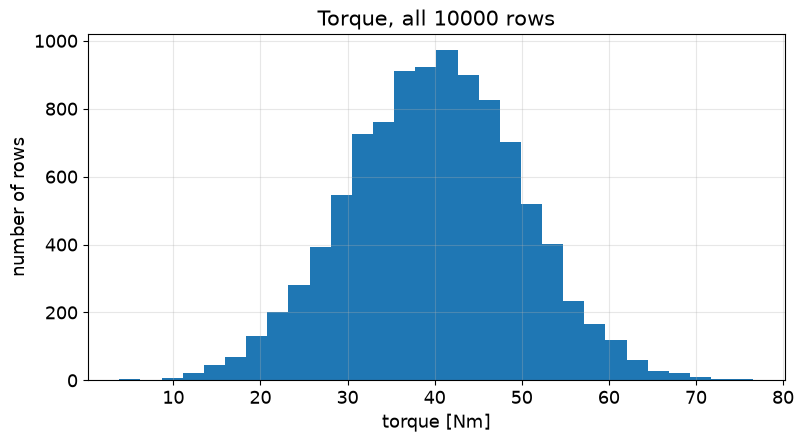

In [33]:
# One worked example: the distribution. Title, BOTH axis labels, one figure per cell.
ai["Torque [Nm]"].plot(kind="hist", bins=30, title="Torque, all 10000 rows")
plt.xlabel("torque [Nm]")
plt.ylabel("number of rows")
plt.show()

That is the pattern: a title, both axes named, one figure per cell, and a sentence
underneath saying what it shows. Two more to go — the comparison and the relationship.

In [34]:
# your turn - the comparison and the relationship, one figure per cell:

### E7 · Five findings

Five numbered sentences, in plain English, that an engineer who does not know Python could
act on. At least one about something wrong, surprising or undocumented.

Write the first one now, before you leave the room, while the file is still fresh.

1.
2.
3.
4.
5.

## Before you go

Today you learned six pieces of Python and seven steps, and you used them to find four
defects in a file that had been published, cited and downloaded thousands of times.

- A category that was two categories, because of one invisible character.
- A gap that was not missing data but a fact about the process.
- A comparison between departments that turns out to be about paperwork.
- Thirty seven values that cannot exist on the scale they are measured on.

None of that required a model. It required looking, in order, and writing down what you
saw.

**Hand in:** `s02_eda_SURNAME_NAME.ipynb`, on Atenea, **Tuesday 29 September, 23:59**.
It is not graded. It is read, and the first ten minutes of the next session are yours.

> A target is not a fact. It is **somebody's definition**.

### Next session

**Session 3 — Wednesday 30 September. Online.** *CRISP-DM in one notebook*: the same
factory, the same file, and the method your theory classes call by its proper name. We
also turn that text column into real dates, and find out what the fifth quarter does to a
time series.

### Data

**Garment Productivity.** Productivity Prediction of Garment Employees [Dataset]. (2020).
UCI Machine Learning Repository. DOI
[10.24432/C51S6D](https://doi.org/10.24432/C51S6D). Licensed under
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). Original study: Imran, A. A.,
Amin, M. N., Islam Rifat, M. R., & Mehreen, S. (2019). *Deep Neural Network Approach for
Predicting the Productivity of Garment Employees.* CoDIT 2019, pages 1402 to 1407.

**AI4I 2020 Predictive Maintenance Dataset.** UCI Machine Learning Repository. DOI
[10.24432/C5HS5C](https://doi.org/10.24432/C5HS5C). Licensed under CC BY 4.0.

Both files are redistributed unmodified in the course repository, with attribution, as
their licence allows. `load_data()` opens a `.csv` or a `.zip`, so either address works.